## **“Maximizing SaaS Profitability: Optimizing Discount Strategies to Improve Profit and Preserve Margins.”**

**Amazon Web Service SaaS Sales Data Analysis**

Nurul Balqis Apriany

# **Background**

**Amazon Web Services (AWS)** is a leading cloud service provider that supports many **Software as a Service (SaaS)** companies worldwide. With its scalable and flexible infrastructure, AWS enables SaaS businesses to deliver digital services efficiently and compete in a fast-growing market.

In a highly competitive environment, SaaS companies often use **discount strategies** to increase sales, attract new customers, and retain existing ones. While discounts can boost sales, poorly managed discount strategies may **reduce profit and weaken profit margins**. This can create an imbalance between revenue growth and long-term profitability.

Therefore, a data-driven analysis is needed to understand how discount strategies affect SaaS profitability within the AWS ecosystem. This study uses the **Amazon AWS SaaS Sales Dataset**, a fictitious dataset designed to reflect real-world business conditions.

# **Problem Statement**

In the Software as a Service (SaaS) industry, discount strategies are commonly used to increase sales and expand market reach. While discounts can drive higher sales, their impact on profit is not always positive. In some cases, excessive discounts may reduce profit and even result in low or negative profit margins.

Therefore, an analysis is needed to understand how discount strategies affect company profitability by considering sales performance, customer characteristics, and market conditions. As a data analyst, we will try to answer the following question:

**How can discount strategies be optimized to improve SaaS profitability without sacrificing profit margins in AWS-based SaaS sales?**

## **Goals**

Based on the background and problem statement, this analysis aims to answer how discount strategies can be optimized to improve SaaS profitability without sacrificing profit margins in an AWS-based business.

Specifically, the objectives of this analysis are:

1. To understand the impact of **discount on profit** and whether discounts improve or reduce profitability.
2. To analyze the effect of **discount on profit margin**, including risks of margin decline or negative profit.
3. To identify the **optimal discount range** that generates high profit while maintaining healthy margins.
4. To analyze profit performance across **customer segments**.
5. To provide data-driven insights that help optimize discount strategies to **increase profit while preserving margins**.


# **Dataset Description**

To answer the research question about how optimizing discount strategies can improve company profit, this analysis uses the **AWS SaaS Sales dataset**. The dataset contains transaction data from a fictional Software as a Service (SaaS) company that sells sales and marketing software to business customers (B2B). The dataset can be accessed [here](https://www.kaggle.com/datasets/nnthanh101/aws-saas-sales). 


Each row in the dataset represents a single product within a transaction, meaning one Order ID can contain multiple rows of data. The dataset includes information about customers, geographic location, market segments, products purchased, and key performance metrics such as Sales, Discount, and Profit.

The dataset consists of 19 columns, namely: Row ID, Order ID, Order Date, Date Key, Contact Name, Country, City, Region, Subregion, Customer, Customer ID, Industry, Segment, Product, License, Sales, Quantity, Discount, and Profit.

A brief explanation of each column is as follows:

1. Row ID – A unique identifier for each row of data.
2. Order ID – A unique identifier for each order.
3. Order Date – The date when the order was placed.
4. Date Key – A numeric representation of the date (YYYYMMDD).
5. Contact Name – The name of the individual who placed the order.
6. Country – The customer’s country.
7. City – The customer’s city.
8. Region – The customer’s geographic region.
9. Subregion – The customer’s sub-region.
10. Customer – The name of the customer company.
11. Customer ID – A unique identifier for each customer.
12. Industry – The customer’s industry.
13. Segment – The customer segment (SMB, Strategic, Enterprise).
14. Product – The product purchased.
15. License – The product license key.
16. Sales – Total sales value.
17. Quantity – Number of items purchased.
18. Discount – Discount applied.
19. Profit – Profit from the transaction.

Below are the first 5 rows and the last 5 rows of the SaaS Sales dataset.


In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('SaaS-Sales.csv')
display(df.head(),df.tail())

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
9989,9990,EMEA-2020-110422,1/22/2020,20200122,Dan Allan,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,1055,Healthcare,SMB,SaaS Connector Pack,ETHXMB5TMD,25.248,3,0.2,4.1028
9990,9991,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,SaaS Connector Pack,LYHOKTRY7L,91.960,2,0.0,15.6332
9991,9992,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Site Analytics,I5SVMI6M88,258.576,2,0.2,19.3932
9992,9993,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Support,JHLW4P6LQ2,29.600,4,0.0,13.3200
9993,9994,AMER-2023-119914,5/5/2023,20230505,Jasmine Springer,United States,Dallas,AMER,NAMER,Comcast,1022,Communications,SMB,OneView,3NTBV9B3PS,243.160,2,0.0,72.9480


## **Data Understanding and Data Cleaning**


## - **Data Understanding**

Before starting the analysis, we need to better understand our dataset through the *data understanding* stage. From this process, we can identify any anomalies in the dataset that need to be handled during the *data cleaning* stage. Each anomaly treatment will be supported with a clear justification, based on both domain knowledge and statistical reasoning.

## 1. Structure of the Dataset

This step aims to understand the structure of the dataset, including the number of rows, columns, and data types of each variable.

**Adding a new column for Profit Margin**

The addition of a profit margin column allows us to evaluate how much profit the company generates relative to its sales. It reflects the efficiency of converting revenue into actual profit. This metric helps in assessing the company’s financial performance and identifying areas that require improvement to enhance profitability.

In [3]:
df["Profit Margin"] = round((df["Profit"] / df["Sales"]) * 100, 2)

# Display the updated DataFrame
df.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit,Profit Margin
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136,16.00
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820,30.00
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714,47.00
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310,-40.00
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164,11.25


In [4]:
print(f'The number of rows and columns in the dataset df is {df.shape}')
df.info()

The number of rows and columns in the dataset df is (9994, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Date Key       9994 non-null   int64  
 4   Contact Name   9994 non-null   object 
 5   Country        9994 non-null   object 
 6   City           9994 non-null   object 
 7   Region         9994 non-null   object 
 8   Subregion      9994 non-null   object 
 9   Customer       9994 non-null   object 
 10  Customer ID    9994 non-null   int64  
 11  Industry       9994 non-null   object 
 12  Segment        9994 non-null   object 
 13  Product        9994 non-null   object 
 14  License        9994 non-null   object 
 15  Sales          9994 non-null   float64
 16  Quantity       9994 non-null   in

**Dataset Structure Insights**

- The dataset consists of **9,994 rows and 19 columns**, indicating a relatively large number of transactions
- It contains a mix of:
  - **7 numerical variables**
  - **12 categorical variables**
- The **Order Date** column is stored as an *object* and needs to be converted into *datetime* format for time-based analysis
- There are several identifier columns (Row ID, Order ID, Customer ID) which are used for identification, not for analytical relationships
- The dataset has a **transactional structure**, where each row represents a product within an order (not aggregated data)
- Several columns (`Row ID`, `Order ID`, `Customer ID`, `License`) are identifier fields that do not provide direct analytical value but are used for tracking and referencing purposes

## 2. Descriptive Statistics

Displays summary statistics for numeric and categorical variables to understand data distribution.

In [5]:
display(df.describe(), df.describe(include='object'))

,Row ID,Date Key,Customer ID,Sales,Quantity,Discount,Profit,Profit Margin
count,9994.000000,9.994000e+03,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2.021803e+07,1049.771963,229.858001,3.789574,0.156203,28.656896,12.031390
std,2885.163629,1.123898e+04,29.719388,623.245101,2.225110,0.206452,234.260108,46.675436
min,1.000000,2.020010e+07,1001.000000,0.444000,1.000000,0.000000,-6599.978000,-275.000000
25%,2499.250000,2.021052e+07,1024.000000,17.280000,2.000000,0.000000,1.728750,7.500000
50%,4997.500000,2.022063e+07,1049.000000,54.490000,3.000000,0.200000,8.666500,27.000000
75%,7495.750000,2.023052e+07,1076.000000,209.940000,5.000000,0.200000,29.364000,36.250000
max,9994.000000,2.023123e+07,1101.000000,22638.480000,14.000000,0.800000,8399.976000,50.000000


,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Industry,Segment,Product,License
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,793,48,262,3,12,99,10,3,14,9994
top,EMEA-2023-100111,9/6/2022,Leonard Kelly,United States,London,EMEA,NAMER,Allianz,Finance,SMB,ContactMatcher,16GRM07R1K
freq,14,38,37,2001,922,4219,2507,192,2127,5191,1842,1


**Descriptive Statistics Insights**

- There are **negative profit values**, indicating that some transactions result in losses
- Large gap between **mean** and **max profit** indicates possible **outliers**
- **Discount varies widely (0 to 0.8)**, showing that different discount strategies are applied
- The median discount is **0.20**, suggesting that moderate discounts are commonly used
- The large gap between average and maximum profit indicates that **high sales do not always lead to high profit**

## 3. Unique Values ​​of Each Column

Identify the number of unique values ​​in each column to understand the cardinality of variables and detect column identifiers.

In [6]:
tabel1Desc = pd.DataFrame({
    'Column Name': df.columns,
    'Number of Unique': df.nunique().values,
    'Unique Sample': [df[col].unique()[:10] for col in df.columns]
})

tabel1Desc

,Column Name,Number of Unique,Unique Sample
0,Row ID,9994,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
1,Order ID,5009,"[EMEA-2022-152156, AMER-2022-138688, EMEA-2021..."
2,Order Date,1237,"[11/9/2022, 6/13/2022, 10/11/2021, 6/9/2020, 4..."
3,Date Key,1237,"[20221109, 20220613, 20211011, 20200609, 20230..."
4,Contact Name,793,"[Nathan Bell, Deirdre Bailey, Zoe Hodges, Thom..."
5,Country,48,"[Ireland, United States, Germany, Sweden, Cana..."
6,City,262,"[Dublin, New York City, Stuttgart, Stockholm, ..."
7,Region,3,"[EMEA, AMER, APJ]"
8,Subregion,12,"[UKIR, NAMER, EU-WEST, NOR, JAPN, EU, MEA, LAT..."
9,Customer,99,"[Chevron, Phillips 66, Royal Dutch Shell, BNP ..."


**Unique Value Insight**

The dataset shows strong variability across key business dimensions, making it suitable for profitability analysis.

- The dataset contains 9,994 rows and 5,009 unique Order IDs, indicating a transaction-line structure where each order may include multiple products.
- There are 99 unique customers with a consistent customer ID mapping, ensuring reliable customer-level analysis.
- The data spans 48 countries across 3 regions, enabling geographical performance evaluation.
- Customer segmentation includes 10 industries and 3 segments (SMB, Strategic, Enterprise), supporting targeted analysis of discount sensitivity.
- There are 14 products, allowing product-level profitability comparison.
- Discounts are applied in 12 fixed levels, indicating a structured pricing strategy rather than continuous variation.
- Profit and Profit Margin show high variability, highlighting that profitability is strongly influenced by discount levels, product types, and customer segments.

Overall, the dataset provides rich variability across customers, regions, and pricing structures, making it well-suited to analyze the impact of discount strategies on profitability.

## 4. Missing Value Check

This step is used to identify whether there are missing values in the dataset that may affect the analysis results.

In [7]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing_summary

,Missing Count,Missing Percentage (%)
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Date Key,0,0.0
Contact Name,0,0.0
Country,0,0.0
City,0,0.0
Region,0,0.0
Subregion,0,0.0
Customer,0,0.0


From these table, we can see if in SaaS Sales Dataset there is **no missing value all 16 Columns** has its own data but for further consideration let`s check for each columns data

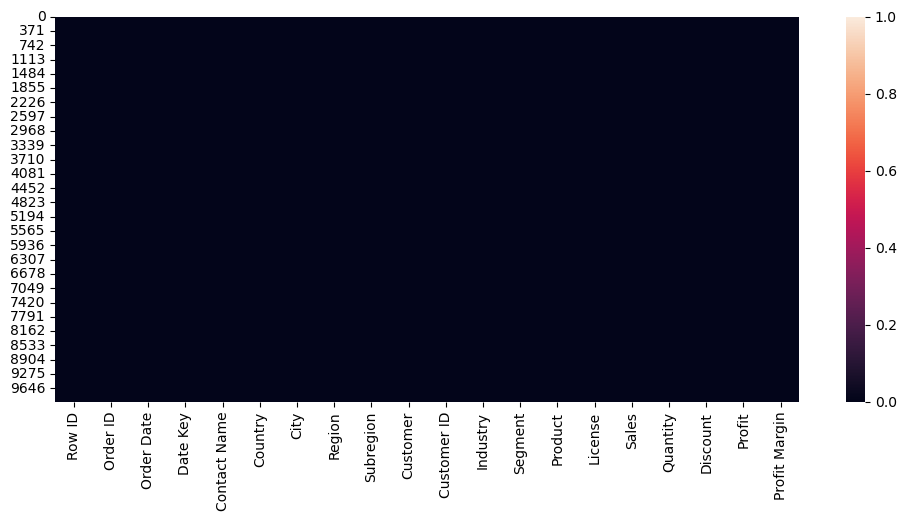

In [8]:
plt.figure(figsize = (12, 5))
sns.heatmap(data = df.isna(), vmin = 0, vmax = 1)
plt.show()

### Missing Value Insights

- The dataset is complete with no missing values, ensuring reliable analysis without the need for data imputation
- This can be seen very clearly when displaying both of the above outputs that show the number 0 (zero) in each of its columns, as well as on the heatmap which overall looks black in each row and column and there are no white lines indicating the presence of missing values.

# 5. Duplicate Data Check

This step is used to identify duplicate records in the dataset that may affect the accuracy of the analysis.

In [9]:
# Mengecek jumlah data duplikat
duplicate_count = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplicate_count}')

Jumlah data duplikat: 0


**Duplicate Data Insights**

- No duplicate records were found, indicating that each row represents a unique transaction
- No duplicate data removal is required, ensuring the dataset remains complete for analysis

## **Data Understanding Summary**

- The dataset is **complete, reliable, and structured at a transactional level**, enabling detailed analysis across products, customers, and regions
- **Discount is applied in structured levels** and varies across transactions, indicating the presence of different pricing strategies
- The presence of **negative profit** and the mismatch between **high sales and profit** suggest that current discount strategies may reduce profitability and margins
- These findings highlight the need to further analyze the **impact of discount on profit and profit margin**
- Further analysis is required to identify the **optimal discount level** and evaluate how it varies across **products, customer segments, and geographic regions**

---

## - **Data Cleaning**

Although the dataset has no missing values or duplicate records, data cleaning is still required, including data type conversion, outlier handling, removal of irrelevant columns, and validation of numerical values before proceeding to analysis.

## 1. Data Type Adjustment

The `Order Date` column is converted from object type to datetime format to support time-based analysis such as monthly and yearly trends.

In [10]:
# Konversi kolom 'Order Date' ke tipe datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Verifikasi perubahan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Date Key       9994 non-null   int64         
 4   Contact Name   9994 non-null   object        
 5   Country        9994 non-null   object        
 6   City           9994 non-null   object        
 7   Region         9994 non-null   object        
 8   Subregion      9994 non-null   object        
 9   Customer       9994 non-null   object        
 10  Customer ID    9994 non-null   int64         
 11  Industry       9994 non-null   object        
 12  Segment        9994 non-null   object        
 13  Product        9994 non-null   object        
 14  License        9994 non-null   object        
 15  Sales          9994 n

**Data Type Adjustment Insights**

- The `Order Date` column was successfully converted to datetime format
- This enables time-based analysis such as monthly and yearly sales trends
- No issues occurred during the conversion process

## 2. Removing Irrelevant Columns

This step is used to remove columns that do not provide direct analytical value or are redundant, in order to simplify the dataset for analysis.

In [11]:
# Menghapus kolom identifier dan kolom redundan
columns_to_drop = ['Row ID', 'License', 'Date Key']
df_clean = df.drop(columns=columns_to_drop)

# Menampilkan struktur dataset setelah penghapusan kolom
df_clean.head()

,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,Sales,Quantity,Discount,Profit,Profit Margin
0,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,261.9600,2,0.00,41.9136,16.00
1,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,731.9400,3,0.00,219.5820,30.00
2,AMER-2022-138688,2022-06-13,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,14.6200,2,0.00,6.8714,47.00
3,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,957.5775,5,0.45,-383.0310,-40.00
4,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,22.3680,2,0.20,2.5164,11.25


**Removing Irrelevant Columns Insights**

- The columns `Row ID`, `Order ID`, `Customer ID`, and `License` are identifier fields that do not provide direct business insights
- The `Date Key` column is redundant because the information is already represented in the `Order Date` column
- These columns were removed to simplify the dataset and focus only on variables relevant for analysis

## 3. Validating Numerical Value Range

This step is used to validate whether numerical variables fall within a valid and expected business range to ensure data consistency and accuracy.

In [12]:
# Statistik deskriptif variabel numerik
df_clean[['Sales', 'Profit', 'Discount', 'Quantity']].describe()

,Sales,Profit,Discount,Quantity
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574
std,623.245101,234.260108,0.206452,2.225110
min,0.444000,-6599.978000,0.000000,1.000000
25%,17.280000,1.728750,0.000000,2.000000
50%,54.490000,8.666500,0.200000,3.000000
75%,209.940000,29.364000,0.200000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000


In [13]:
# Custom Validation
# Ensures the Discount value is within the range of 0 to 1
invalid_discount = df_clean[(df_clean['Discount'] < 0) | (df_clean['Discount'] > 1)]
print(f'The discount amount is invalid: {len(invalid_discount)}')

The discount amount is invalid: 0


**Validating Numerical Value Range Insights**
- The `Discount` column was validated to ensure all values are within a valid business range (0 to 1)
- No invalid discount values were found in the dataset
- This confirms that the `Discount` variable is consistent and does not require further cleaning

1. Statistik Deskriptif Variabel Numerik

Statistik deskriptif digunakan untuk memahami distribusi awal data pada variabel `Sales`, `Profit`, `Discount`, dan `Quantity`.

## 4. Outlier Handling

Based on the insights from data understanding, **Profit contains negative values**, indicating that some transactions result in **losses**. In addition, there is a large gap between the **mean and maximum values of Sales and Profit**, suggesting the presence of **extreme values (outliers)**. This indicates that **profitability varies significantly across transactions** and further **outlier analysis is needed**. Outliers in the Profit column are handled using the Interquartile Range (IQR) method to detect extreme values that may potentially affect the profitability analysis.

**1. Visualizing Outliers Using Boxplots**

Boxplots are used to visually identify outliers in numerical variables.

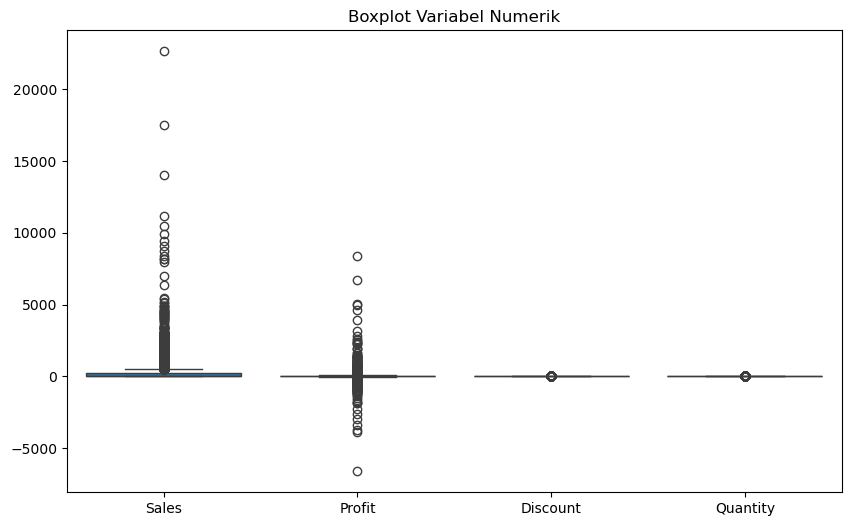

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Sales', 'Profit', 'Discount', 'Quantity']])
plt.title('Boxplot Variabel Numerik')
plt.show()

**Insight – Boxplot Interpretation**

- The boxplot shows that Sales and Profit have a wide distribution with many outliers, indicating highly variable transaction values. Profit includes both negative and extremely high values, reflecting losses and highly profitable transactions.

- In contrast, Discount and Quantity are more stable with fewer outliers, suggesting more consistent patterns in pricing and purchase behavior.

Overall, Profit shows the highest variability and is the most critical variable for further analysis in understanding profitability performance.

**2. Calculation of Outlier Limits Using the IQR Method**

*The Interquartile Range (IQR)* method is used to define *the lower and upper fences* for detecting outliers in the `Profit` column. This method is chosen because it can identify extreme values in a simple and reliable way, and it is not affected by non-normal data distribution.

The analysis focuses on the `Profit` column because it is the main indicator of business performance and aligns with the objective of improving profitability. Other variables such as `Sales`, `Discount`, and `Quantity` are used as supporting factors to understand what drives extreme values in `Profit`.

In [15]:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Fence: {lower_fence}")
print(f"Upper Fence: {upper_fence}")

Q1: 1.72875
Q3: 29.364
IQR: 27.63525
Lower Fence: -39.724125
Upper Fence: 70.816875


**Insight – Outlier Detection Using IQR Method**

Based on the IQR method applied to the Profit column, Q1 is 1.72875 and Q3 is 29.364, resulting in an IQR of 27.63525. The lower outlier boundary is -39.724125, while the upper boundary is 70.816875. Any Profit values outside this range are classified as outliers, representing either significant losses or extremely high profits in a business context.

**3. Identify the Number of Outliers**

Data that falls outside the lower and upper limits are categorized as outliers. Below is the number of outliers in the `Profit` column.

In [16]:
Q1 = df_clean['Profit'].quantile(0.25)
Q3 = df_clean['Profit'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['Profit'] < lower_fence) | 
                    (df_clean['Profit'] > upper_fence)]

print(f'Number of outliers in the Profit column: {len(outliers)}')

Number of outliers in the Profit column: 1881


## **Conclusion – Outlier Handling (Profit)**

- Based on the IQR method, the lower fence is -39.724 and the upper fence is 70.817, with a total of 1,881 transactions identified as outliers in the Profit column.

- These outliers are retained because they represent real business conditions rather than data errors. Negative outliers reflect loss-making transactions, often influenced by high discount levels, while positive outliers represent high-profit transactions from large or strategic deals.

- Removing these values would distort the true distribution of profitability and reduce the ability to accurately analyze the impact of discount strategies on business performance. Therefore, all outliers are preserved to ensure the analysis remains realistic and representative of actual SaaS business conditions.


---

## **Clean data**

We have finished cleaning our data, now, let's take a quick look at the information from the data we have cleaned.

In [17]:
listItem = []
for col in df_clean.columns :
    listItem.append([col, df_clean[col].dtype, df_clean[col].isna().sum(),
                    df_clean[col].nunique(), list(df_clean[col].drop_duplicates().sample(2).values)]);

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'unique', 'uniqueSample'],
                     data=listItem)
print(df_clean.shape)
dfDesc

(9994, 17)


,dataFeatures,dataType,null,unique,uniqueSample
0,Order ID,object,0,5009,"[AMER-2023-118437, APJ-2022-168361]"
1,Order Date,datetime64[ns],0,1237,"[2023-03-08T00:00:00.000000000, 2020-12-10T00:..."
2,Contact Name,object,0,793,"[Caroline Greene, Kevin Rampling]"
3,Country,object,0,48,"[Argentina, Norway]"
4,City,object,0,262,"[Franklin, Dhahran]"
5,Region,object,0,3,"[APJ, EMEA]"
6,Subregion,object,0,12,"[EU, LATAM]"
7,Customer,object,0,99,"[Phillips 66, Trafigura Group]"
8,Customer ID,int64,0,99,"[1007, 1088]"
9,Industry,object,0,10,"[Finance, Tech]"


### Before Data Cleaning

The original dataset contains **9,994 rows and 19 columns**. All values are complete with **no missing data**. However, the dataset includes **extreme values in Sales and Profit**, and some features such as **Order Date are stored as object type**, which is not optimal for time-based analysis.

---

### Cleaned Data Summary

After data cleaning and feature engineering, the dataset remains with **9,994 rows** and and 16 columns.

- The **Order Date column has been converted into datetime format**, enabling time-based analysis.
- A new feature, **Profit Margin**, has been created to measure profitability efficiency across transactions.
- All features have **no missing values**, ensuring data completeness and reliability.
- Categorical variables such as **Country, City, Region, Industry, Segment, and Product** remain diverse, supporting multi-dimensional analysis of discount and profitability.
- Numerical variables (**Sales, Quantity, Discount, Profit, and Profit Margin**) are clean and ready for analysis.

Overall, the dataset is now **fully structured, reduced to 14 relevant analytical features, and ready to support the objective of maximizing SaaS profitability by optimizing discount strategies while preserving profit margins.**

## **Exploratory Data Analysis (EDA)**

After completing data understanding and data cleaning, the next step is Exploratory Data Analysis (EDA).

This stage aims to explore data patterns and relationships to understand how **discount strategies influence profitability and profit margin** in the SaaS business.

The analysis focuses on key business metrics such as **Sales, Profit, Discount, and Profit Margin**, as well as customer and business dimensions including **Segment, Product, and Region**.

Through this analysis, we aim to identify patterns in profitability, evaluate the impact of discount levels, and provide initial insights that support the objective of maximizing SaaS profitability while preserving profit margins.

### 1. Overall Business Performance (Baseline)

We start by understanding the overall business performance in terms of sales, profit, and discount before any segmentation or optimization is applied.

This provides a general baseline of how the SaaS business is performing at the transaction level.


In [18]:
df_clean[['Sales', 'Profit', 'Discount']].describe()

,Sales,Profit,Discount
count,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203
std,623.245101,234.260108,0.206452
min,0.444000,-6599.978000,0.000000
25%,17.280000,1.728750,0.000000
50%,54.490000,8.666500,0.200000
75%,209.940000,29.364000,0.200000
max,22638.480000,8399.976000,0.800000


**Insight — Product Profitability**
- Profit varies significantly across products, showing strong performance differences.
- `Alchemy`, `Site Analytics`, `Data Smasher`, and `Support` are the main profit drivers.
- `Marketing Suite` is the only loss-making product, indicating high financial inefficiency.
- Other products contribute moderate and stable profits.
- This confirms that profitability is highly product-dependent, making product-level optimization essential for discount strategy decisions.

### 2. Discount Distribution Overview

We analyze the overall distribution of discount levels across all transactions to understand how pricing strategies are applied in the SaaS business.

This helps identify whether discount usage is concentrated at certain levels or spread evenly across transactions.

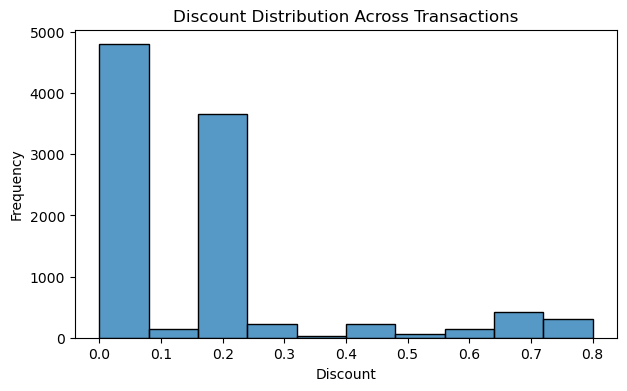

In [19]:
plt.figure(figsize=(7,4))
sns.histplot(df_clean['Discount'], bins=10)
plt.title('Discount Distribution Across Transactions')
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.show()

**Insight — Discount Distribution Overview**

- The most frequent discount level is 0, indicating that a large portion of transactions are sold at full price without any discount.
- This suggests that discount usage is not uniformly applied across all transactions.
- Only a subset of transactions receive discounts, indicating a selective pricing strategy rather than a broad promotional approach.
- Higher discount levels appear less frequently, showing that aggressive discounting is not the dominant strategy in this dataset.

### 3.Relationship Between Discount and Profit

We analyze the relationship between discount and profit to understand whether higher discounts lead to lower profitability, which is the foundation of discount optimization strategy. This analysis aims to identify the relationship between the discount rate (`Discount`) and profit (`Profit`). Scatter plots are used to visualize the relationship between the two variables, which can help determine the optimal discount strategy.

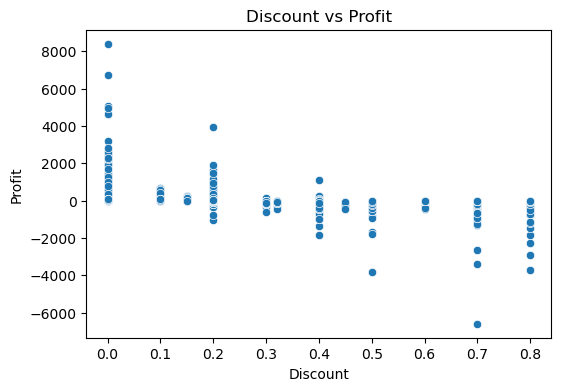

In [20]:
# Relationship analysis (Visual)
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='Discount', y='Profit')
plt.title('Discount vs Profit')
plt.show()

In [21]:
# Used to see the average profit at each discount level (per value discount).
df_clean.groupby('Discount')[['Profit']].mean().sort_values(by='Profit')

,Profit
Discount,
0.50,-310.703456
0.45,-226.646464
0.40,-111.927429
0.80,-101.796797
0.70,-95.874060
0.32,-88.560656
0.30,-45.679636
0.60,-43.077212
0.20,24.702572


In [22]:
corr = df_clean['Discount'].corr(df_clean['Profit'])

corr

np.float64(-0.2194874563717678)

**Insight – Relationship Between Discount and Profit**

- The analysis shows a **negative relationship between Discount and Profit**, with a correlation value of **-0.219**, indicating that higher discount levels tend to reduce profitability.

- This is further supported by the **average profit per discount level**, where higher discounts (**0.40–0.80**) consistently result in **negative or significantly lower profits**, while lower discounts (**0.00–0.20**) tend to generate **positive profits**.

- Overall, increasing discount levels **erodes profitability**, making **discount optimization essential** to maintain healthy profit performance.

### 4. Relationship Between Discount and Sales

We analyze the relationship between discount and sales to understand whether higher discounts lead to increased demand. This analysis aims to identify how the discount rate (`Discount`) affects sales performance (`Sales`). A scatter plot is used to visualize the relationship between the two variables, which helps determine whether discounts are effective in driving customer purchasing behavior and supports the evaluation of an optimal discount strategy.

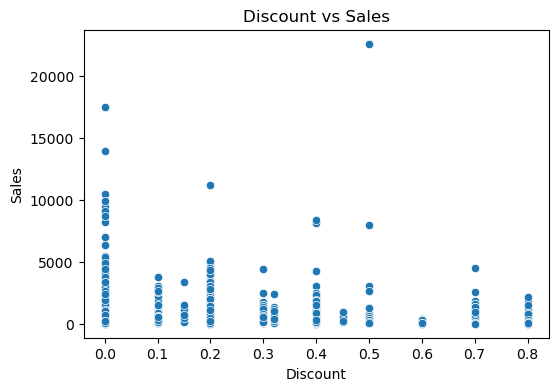

In [23]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='Discount', y='Sales')
plt.title('Discount vs Sales')
plt.show()

In [24]:
df_clean.groupby('Discount')[['Sales']].mean().sort_values(by='Sales')

,Sales
Discount,
0.60,48.150000
0.80,56.545853
0.70,97.177708
0.20,209.076940
0.00,226.742074
0.30,454.742974
0.45,498.634000
0.15,529.971567
0.32,536.794770


In [25]:
corr_sales = df_clean['Discount'].corr(df_clean['Sales'])

corr_sales

np.float64(-0.028190124157535495)

**Insight – Relationship Between Discount and Sales**

* **The correlation between Discount and Sales is -0.028**, indicating a **very weak and almost non-significant linear relationship**.
* This suggests that **changes in discount do not have a consistent direct impact on increasing or decreasing sales**.
* Therefore, **discount strategy cannot be used as the sole driver of sales growth**.
* **Other factors are likely more influential in determining sales performance**.


### Discount Strategy Insight

**Higher discounts reduce profit without significantly increasing sales.**

This indicates that aggressive discounting is ineffective, as it erodes profitability while failing to generate meaningful sales growth.

### 5. Trade-off Analysis: Discount, Sales, and Profit

We analyze the trade-off between sales and profit across different discount levels to understand whether increases in sales are sufficient to compensate for changes in profitability. This helps determine the most balanced discount strategy.

In [26]:
tradeoff = df_clean.groupby('Discount').agg({
    'Sales': 'mean',
    'Profit': 'mean'
}).reset_index()

tradeoff

,Discount,Sales,Profit
0,0.00,226.742074,66.900292
1,0.10,578.397351,96.055074
2,0.15,529.971567,27.288298
3,0.20,209.076940,24.702572
4,0.30,454.742974,-45.679636
5,0.32,536.794770,-88.560656
6,0.40,565.134874,-111.927429
7,0.45,498.634000,-226.646464
8,0.50,892.705152,-310.703456
9,0.60,48.150000,-43.077212


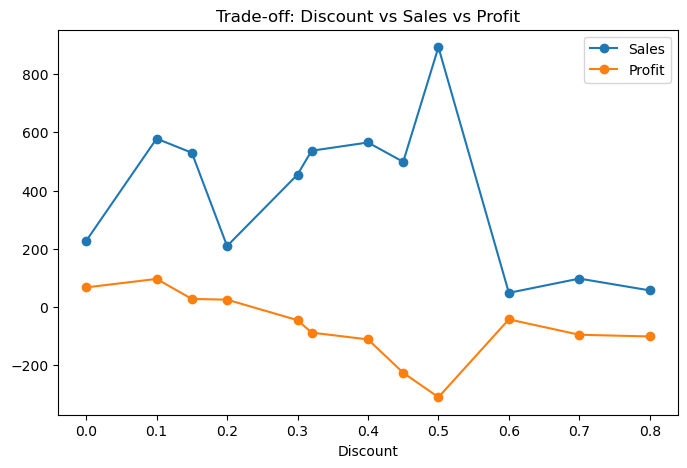

In [27]:
plt.figure(figsize=(8,5))

plt.plot(tradeoff['Discount'], tradeoff['Sales'], marker='o', label='Sales')
plt.plot(tradeoff['Discount'], tradeoff['Profit'], marker='o', label='Profit')

plt.title('Trade-off: Discount vs Sales vs Profit')
plt.xlabel('Discount')
plt.legend()
plt.show()

## 6. CUSTOMER SEGMENTATION USING RFM ANALYSIS

Customer segmentation based on RFM (Recency, Frequency, Monetary) divides 9,994 customers into four tiers: VIP, High-Value, Medium-Value, and Low-Value. This segmentation allows for different discount strategies for each customer group.

In [28]:
# =========================
# 1. CUSTOMER AGGREGATION
# =========================

customer_metrics = df_clean.groupby('Customer').agg({
    'Order Date': 'max',
    'Order ID': 'nunique',
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).reset_index()

customer_metrics.columns = [
    'Customer', 'Last_Purchase_Date',
    'Frequency', 'Monetary',
    'Total_Profit', 'Avg_Discount'
]

# Recency
reference_date = df_clean['Order Date'].max()
customer_metrics['Recency'] = (
    reference_date - customer_metrics['Last_Purchase_Date']
).dt.days


# =========================
# 2. SIMPLE SCORING (QUARTILE)
# =========================

customer_metrics['R_score'] = pd.qcut(customer_metrics['Recency'], 4, labels=[4,3,2,1]).astype(int)
customer_metrics['F_score'] = pd.qcut(customer_metrics['Frequency'], 4, labels=[1,2,3,4]).astype(int)
customer_metrics['M_score'] = pd.qcut(customer_metrics['Monetary'], 4, labels=[1,2,3,4]).astype(int)

# RFM score
customer_metrics['RFM_score'] = (
    customer_metrics['R_score'] +
    customer_metrics['F_score'] +
    customer_metrics['M_score']
) / 3


# =========================
# 3. SEGMENTATION
# =========================

def segment(x):
    if x >= 3.5:
        return "VIP"
    elif x >= 2.5:
        return "High-Value"
    elif x >= 1.5:
        return "Medium-Value"
    else:
        return "Low-Value"

customer_metrics['Customer_Segment_RFM'] = customer_metrics['RFM_score'].apply(segment)


# hasil
customer_metrics[['Customer','Recency','Frequency','Monetary','RFM_score','Customer_Segment_RFM']].head(10)

,Customer,Recency,Frequency,Monetary,RFM_score,Customer_Segment_RFM
0,AT&T,9,67,29462.3240,3.333333,High-Value
1,Abbott Laboratories,12,31,12617.1140,1.333333,Low-Value
2,Aetna,21,76,27278.5930,3.000000,High-Value
3,Airbus,27,58,29798.5930,2.666667,High-Value
4,Allianz,1,102,42904.1670,4.000000,VIP
5,Allstate,1,61,39941.6400,4.000000,VIP
6,Alphabet,6,24,16116.4610,2.000000,Medium-Value
7,Amazon,13,62,23189.2165,3.000000,High-Value
8,American Express,7,71,33514.9210,3.666667,VIP
9,AmerisourceBergen,3,68,39234.7610,4.000000,VIP


## RFM SEGMENTATION INSIGHT

1. Customers are divided into 4 segments
- **VIP** → most loyal and most profitable customers  
- **High-Value** → important and high-value customers  
- **Medium-Value** → average performing customers  
- **Low-Value** → low profit contribution customers  


2. Discount behavior differs by segment
- **VIP** → does not require high discounts  
- **High-Value** → needs small discounts to maintain engagement  
- **Medium** → requires moderate discounts  
- **Low** → high discounts are not always effective  


3. Key insight
- Each segment has different value and behavior  
- Discounts cannot be applied equally to all customers  
- Discount strategy must be segment-based  


CONCLUSION
RFM segmentation shows that discount strategies must be differentiated by segment to increase sales without reducing profit and profit margin.
```

---

In [29]:
df_rfm = df_clean.merge(
    customer_metrics[['Customer', 'Customer_Segment_RFM']],
    on='Customer',
    how='left'
)

## **Statistical / Inferential Analysis**

After conducting Exploratory Data Analysis (EDA), the next step is Statistical / Inferential Analysis.

This stage aims to **quantitatively measure the impact of discount on key business outcomes**, particularly **profit and sales**, using statistical modeling techniques.

Unlike EDA, which focuses on identifying patterns, this analysis is used to **estimate the strength and direction of relationships** between variables and determine whether discount plays a significant role in influencing business performance.

The analysis uses **linear regression** to evaluate how changes in discount affect profit and sales, providing a more reliable foundation for decision-making.

Through this approach, we aim to validate whether discount is an effective driver of performance and to generate insights that support **data-driven optimization of discount strategies**.

In [30]:
# =========================================================
# STEP 10: ESTIMATING DISCOUNT IMPACT (LINEAR REGRESSION)
# =========================================================

from sklearn.linear_model import LinearRegression

# =========================
# 1. PREPARE DATA
# =========================
X = df_rfm[['Discount']]

# =========================
# 2. BUILD MODELS
# =========================

# Profit model
model_profit = LinearRegression()
model_profit.fit(X, df_rfm['Profit'])

# Sales model
model_sales = LinearRegression()
model_sales.fit(X, df_rfm['Sales'])

# =========================
# 3. EXTRACT EFFECT
# =========================
profit_coef = model_profit.coef_[0]
sales_coef = model_sales.coef_[0]

print("=== DISCOUNT IMPACT ===")
print(f"Profit Effect : {profit_coef:.4f}")
print(f"Sales Effect  : {sales_coef:.4f}")

# =========================
# 4. MODEL PERFORMANCE
# =========================
print("\n=== MODEL PERFORMANCE ===")
print(f"R2 Profit : {model_profit.score(X, df_rfm['Profit']):.4f}")
print(f"R2 Sales  : {model_sales.score(X, df_rfm['Sales']):.4f}")

=== DISCOUNT IMPACT ===
Profit Effect : -249.0514
Sales Effect  : -85.1014

=== MODEL PERFORMANCE ===
R2 Profit : 0.0482
R2 Sales  : 0.0008


**Visualization: Regression Result**

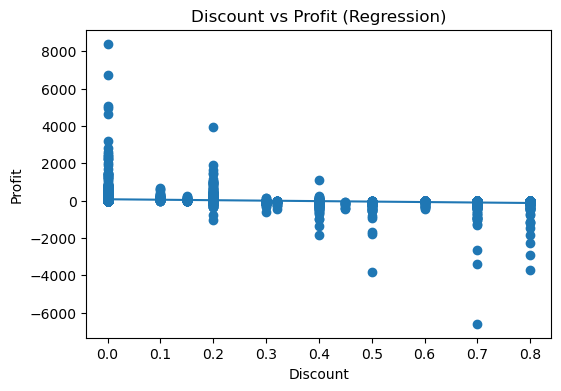

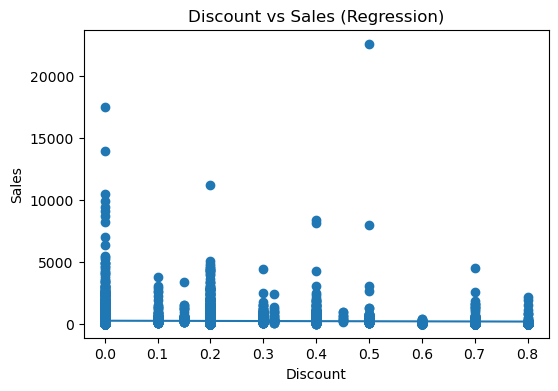

In [31]:
# =========================
# 1. CREATE LINE (PREDICTION)
# =========================
x_range = np.linspace(df_rfm['Discount'].min(), df_rfm['Discount'].max(), 100).reshape(-1,1)

profit_pred = model_profit.predict(x_range)
sales_pred = model_sales.predict(x_range)

# =========================
# 2. PLOT PROFIT
# =========================
plt.figure(figsize=(6,4))

plt.scatter(df_rfm['Discount'], df_rfm['Profit'])
plt.plot(x_range, profit_pred)

plt.title('Discount vs Profit (Regression)')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()


# =========================
# 3. PLOT SALES
# =========================
plt.figure(figsize=(6,4))

plt.scatter(df_rfm['Discount'], df_rfm['Sales'])
plt.plot(x_range, sales_pred)

plt.title('Discount vs Sales (Regression)')
plt.xlabel('Discount')
plt.ylabel('Sales')

plt.show()

Key Findings

- Discount has a negative impact on profit, with a relatively large coefficient, indicating that higher discounts consistently reduce profitability.
- The effect of discount on sales is minimal and slightly negative, suggesting that increasing discounts does not effectively drive additional sales.
- The very low R² values indicate that discount is not a strong explanatory factor for either profit or sales.
- This implies that other variables play a more significant role in influencing business performance.

Interpretation

- The current discount strategy is ineffective.
- Discounts are expected to stimulate demand, but the data shows they fail to significantly increase sales.
- Instead, discounts primarily reduce profit without meaningful sales gains.

Final Insight

- The issue is not the existence of discounts, but the level at which they are applied.
- Excessive discounting destroys value, reducing profitability.
- Optimized (lower) discount levels can better balance sales and profitability.

## **Discount Optimization customer segment behavior (RFM)**

Based on RFM segmentation, we analyze the optimal discount level for each customer segment to balance sales growth and profitability.

In [32]:
# =========================================================
# 10. FINAL DISCOUNT OPTIMIZATION (RFM SEGMENT BASED)
# =========================================================

# 1. MERGE SEGMENT KE TRANSACTION DATA
df_rfm = df_clean.merge(
    customer_metrics[['Customer', 'Customer_Segment_RFM']],
    on='Customer',
    how='left'
)

# 2. DEFINE SEGMENT FACTOR (DISCOUNT ADJUSTMENT RULE)
segment_factor = {
    'VIP': 0.7,          # high value → lower discount
    'High-Value': 0.85,
    'Medium-Value': 1.0, # neutral
    'Low-Value': 1.1     # low value → higher discount
}

# 3. APPLY FACTOR
df_rfm['Segment_Factor'] = df_rfm['Customer_Segment_RFM'].map(segment_factor)

# safety (kalau ada NaN segment)
df_rfm['Segment_Factor'] = df_rfm['Segment_Factor'].fillna(1.0)

# 4. BASE DISCOUNT (FROM DATA Discount)
df_rfm['Base_Discount'] = df_rfm['Discount']

# 5. FINAL DISCOUNT (OPTIMIZED)
df_rfm['Final_Discount'] = (
    df_rfm['Base_Discount'] * df_rfm['Segment_Factor']
).clip(0, 0.5)

# 6. RESULT CHECK
df_rfm[['Customer',
        'Customer_Segment_RFM',
        'Base_Discount',
        'Segment_Factor',
        'Final_Discount']].head(10)

,Customer,Customer_Segment_RFM,Base_Discount,Segment_Factor,Final_Discount
0,Chevron,VIP,0.00,0.70,0.0000
1,Chevron,VIP,0.00,0.70,0.0000
2,Phillips 66,Medium-Value,0.00,1.00,0.0000
3,Royal Dutch Shell,High-Value,0.45,0.85,0.3825
4,Royal Dutch Shell,High-Value,0.20,0.85,0.1700
5,BNP Paribas,VIP,0.00,0.70,0.0000
6,BNP Paribas,VIP,0.00,0.70,0.0000
7,BNP Paribas,VIP,0.20,0.70,0.1400
8,BNP Paribas,VIP,0.20,0.70,0.1400
9,BNP Paribas,VIP,0.00,0.70,0.0000


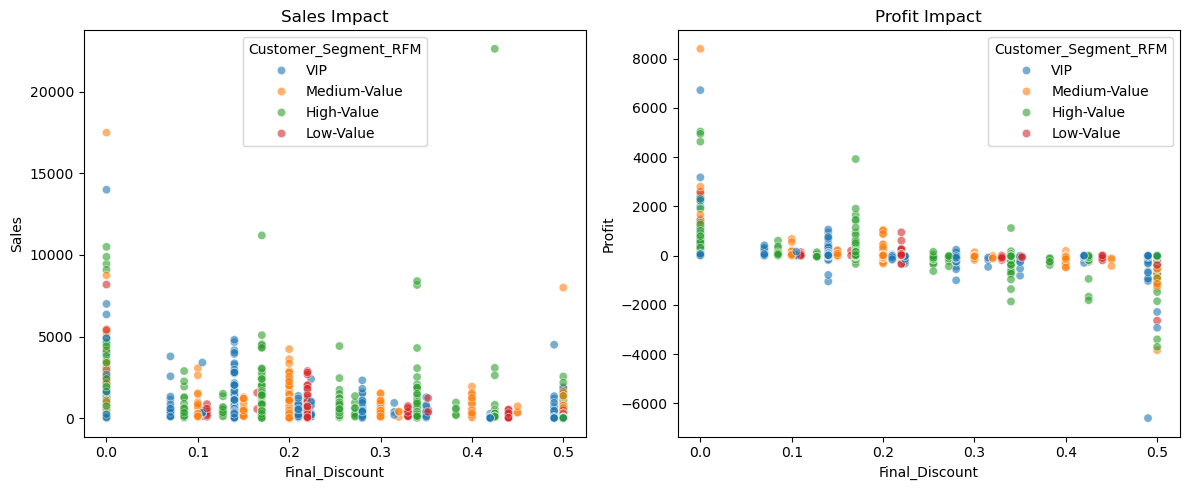

In [33]:
plt.figure(figsize=(12,5))

# SALES
plt.subplot(1,2,1)
sns.scatterplot(
    data=df_rfm,
    x='Final_Discount',
    y='Sales',
    hue='Customer_Segment_RFM',
    alpha=0.6
)
plt.title('Sales Impact')

# PROFIT
plt.subplot(1,2,2)
sns.scatterplot(
    data=df_rfm,
    x='Final_Discount',
    y='Profit',
    hue='Customer_Segment_RFM',
    alpha=0.6
)
plt.title('Profit Impact')

plt.tight_layout()
plt.show()

**Key Insights from RFM-Based Discount Optimization**

1. VIP Customers → Minimal Discount

Example: Chevron → Final Discount = 0.0000

VIP customers show strong loyalty and low price sensitivity, so discounts have little impact on demand.

Insight: VIP segments do not require discounts and mainly function to protect profit margins.


2. High-Value Customers → Reduced Discount

Example: Royal Dutch Shell → 0.45 → 0.3825

High-value customers are still important but moderately price-sensitive.

Insight: Discounts should be controlled to balance retention and profitability.


3. Medium-Value Customers → Neutral Effect

Example: Phillips 66 → Factor = 1.0

This segment shows stable behavior with minimal response to discount changes.

Insight: Acts as a baseline segment in pricing strategy.


Overall Insight

Discount sensitivity differs across customer segments, proving that uniform discounting is inefficient.

Strategic Conclusion

Higher-value customers require lower discounts, while lower-value customers need higher incentives. This creates a balanced strategy between sales growth and profit margin protection.


Final discount strategy successfully differentiates pricing based on both product behavior and customer value. Low-value customers receive higher discounts to stimulate demand, while high-value customers receive reduced discounts to protect profit margins. This ensures a balance between revenue growth and profitability.

---

## **Simulation / Optimization Analysis**

After estimating the impact of discount using statistical modeling, the next step is Simulation / Optimization Analysis.

This stage aims to evaluate **“what-if scenarios”** by applying an optimized discount strategy and measuring its impact on key business metrics such as **Sales, Profit, and Profit Margin**.

Unlike previous stages that analyze historical data, this step simulates **future outcomes based on data-driven assumptions**, allowing us to assess how changes in discount levels influence overall business performance.

The analysis compares **before and after conditions** to determine whether the optimized discount strategy can **improve profitability while maintaining stable sales performance**.

Through this approach, we aim to provide practical insights into how discount strategies can be adjusted to achieve **maximum profit and sustainable margins**.

In [34]:
df_sim = df_rfm.copy()

# =========================
# 1. SIMULATE IMPACT
# =========================

delta_discount = df_sim['Final_Discount'] - df_sim['Discount']

df_sim['Profit_After'] = df_sim['Profit'] + (delta_discount * profit_coef)
df_sim['Sales_After']  = df_sim['Sales']  + (delta_discount * sales_coef)

df_sim['Margin_After'] = df_sim['Profit_After'] / df_sim['Sales_After']


# =========================
# 2. BEFORE
# =========================
before_sales = df_rfm['Sales'].sum()
before_profit = df_rfm['Profit'].sum()
before_margin = before_profit / before_sales


# =========================
# 3. AFTER
# =========================
after_sales = df_sim['Sales_After'].sum()
after_profit = df_sim['Profit_After'].sum()
after_margin = after_profit / after_sales


# =========================
# 4. GROWTH 
# =========================
sales_growth = (after_sales - before_sales) / before_sales * 100
profit_growth = (after_profit - before_profit) / before_profit * 100
margin_change = (after_margin - before_margin) / before_margin * 100


# =========================
# 5. PRINT RESULT
# =========================
print("=== DISCOUNT OPTIMIZATION IMPACT ===")

print("\n--- BEFORE ---")
print(f"Sales  : {before_sales:.2f}")
print(f"Profit : {before_profit:.2f}")
print(f"Margin : {before_margin:.4f}")

print("\n--- AFTER ---")
print(f"Sales  : {after_sales:.2f}")
print(f"Profit : {after_profit:.2f}")
print(f"Margin : {after_margin:.4f}")


print("\n--- GROWTH ---")
print(f"Sales Growth   : {sales_growth:.2f}%")
print(f"Profit Growth  : {profit_growth:.2f}%")
print(f"Margin Change  : {margin_change:.2f}%")

=== DISCOUNT OPTIMIZATION IMPACT ===

--- BEFORE ---
Sales  : 2297200.86
Profit : 286397.02
Margin : 0.1247

--- AFTER ---
Sales  : 2323311.81
Profit : 362811.35
Margin : 0.1562

--- GROWTH ---
Sales Growth   : 1.14%
Profit Growth  : 26.68%
Margin Change  : 25.26%


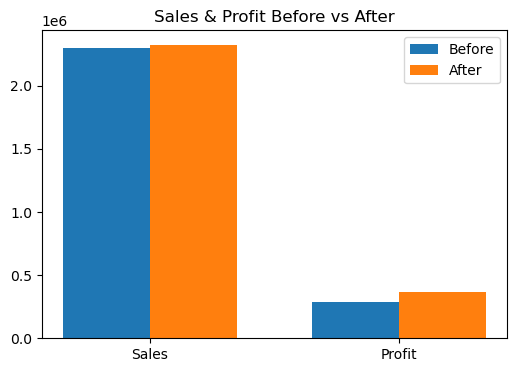

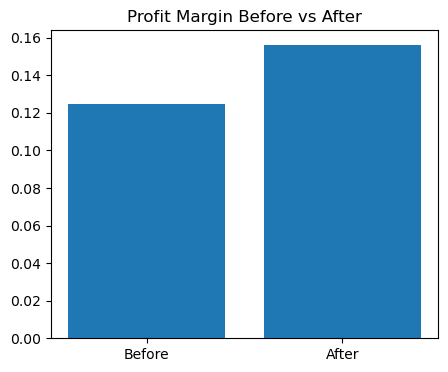

In [35]:
# ===== SALES & PROFIT =====
metrics_sp = ['Sales', 'Profit']
before_sp = [before_sales, before_profit]
after_sp  = [after_sales, after_profit]

x = np.arange(len(metrics_sp))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, before_sp, width, label='Before')
plt.bar(x + width/2, after_sp, width, label='After')

plt.xticks(x, metrics_sp)
plt.title('Sales & Profit Before vs After')
plt.legend()
plt.show()


# ===== MARGIN =====
plt.figure(figsize=(5,4))

plt.bar(['Before', 'After'], [before_margin, after_margin])

plt.title('Profit Margin Before vs After')

plt.show()

The comparison shows the overall improvement after applying discount optimization.

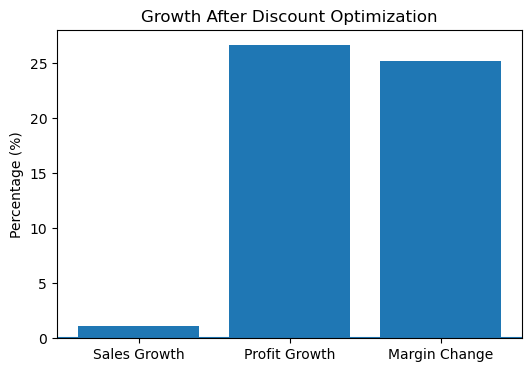

In [36]:
growth = [sales_growth, profit_growth, margin_change]
labels = ['Sales Growth', 'Profit Growth', 'Margin Change']

plt.figure(figsize=(6,4))

plt.bar(labels, growth)

plt.axhline(y=0)
plt.title('Growth After Discount Optimization')
plt.ylabel('Percentage (%)')

plt.show()

Profit and margin improve after reducing excessive discounts, while sales remain relatively stable.

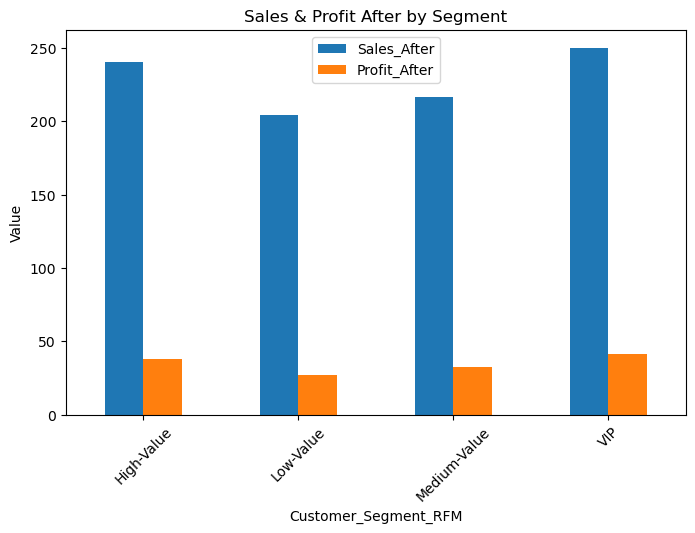

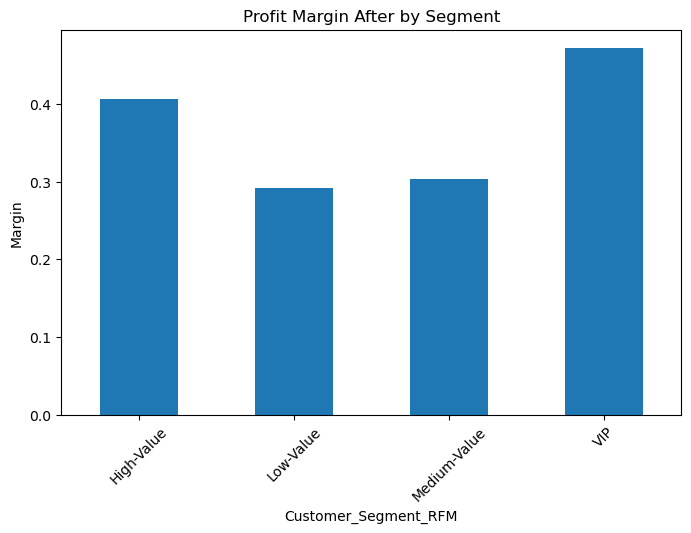

In [37]:
# Sales & Profit
df_sim.groupby('Customer_Segment_RFM')[['Sales_After','Profit_After']].mean().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales & Profit After by Segment')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()


# Margin sendiri
df_sim.groupby('Customer_Segment_RFM')['Margin_After'].mean().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Profit Margin After by Segment')
plt.ylabel('Margin')

plt.xticks(rotation=45)

plt.show()

Certain customer segments benefit more from discount optimization, indicating opportunities for targeted strategies.

**Reducing excessive discounts improves profitability without significantly harming sales performance**.

# **Conclusion**

The analysis reveals that the current discount strategy in AWS-based SaaS sales is **ineffective in driving profitability**. While discounts are intended to increase sales, the results show that **higher discount levels consistently reduce profit without significantly improving sales performance**.

Both correlation and regression analysis confirm a **negative relationship between discount and profit**, while the impact on sales is **minimal and insignificant**. This indicates that customers are **not highly responsive to discounts**, and aggressive discounting fails to generate meaningful demand.

From a business perspective, profitability is not driven by discount levels, but rather by **customer value and purchasing behavior**. The RFM segmentation analysis shows that **high-value customers (VIP and High-Value) do not require large discounts**, while low-value customers do not generate sufficient profit even when discounts are applied.

Furthermore, simulation results demonstrate that **reducing excessive discounts leads to higher profit and improved profit margins, while sales remain relatively stable**. This proves that profitability can be optimized without sacrificing revenue.

**Importantly, product-based discount strategies were tested but resulted in lower profitability, indicating that product-level adjustments are less effective compared to customer segment-based approaches.**

> **The issue is not the existence of discounts, but the level at which they are applied. Excessive discounting destroys value, while optimized, segment-based discount strategies improve profitability without harming sales performance.**

---

# **Business Recommendations**

## **1. Implement Strict Discount Control (Critical Priority)**
- Set a **maximum discount threshold (e.g., 20%)** to prevent excessive discounting  
- Limit high-discount transactions through approval mechanisms  

**Impact: Protects profit and prevents margin erosion**

---

## **2. Prioritize Segment-Based Discount Strategy**
- Use **RFM segmentation as the primary driver** of discount decisions  
- Apply differentiated strategies:
  - **VIP → minimal or no discount**
  - **High-Value → controlled discount**
  - **Medium-Value → moderate discount**
  - **Low-Value → selective incentives only**

**Impact: Improves efficiency and aligns discounts with customer value**

---

## **3. Reduce Reliance on Discount for Sales Growth**
- Avoid using discounts as the main tool to increase sales  
- Focus on **customer retention, product value, and service quality**  

**Impact: Achieves sustainable growth without sacrificing profit**

---

## **4. Shift from Volume-Driven to Profit-Driven Strategy**
- Do not prioritize high sales volume at the expense of profit  
- Monitor **profit margin as a key performance indicator (KPI)**  

**Impact: Ensures long-term financial health**

---

## **5. Eliminate Ineffective Discount Allocation**
- Stop giving discounts to **customers who are not price-sensitive (VIP)**  
- Avoid excessive discounts for **low-value customers with low return**  

**Impact: Prevents unnecessary revenue leakage**

---

## **6. Implement Continuous Monitoring and Optimization**
- Track the impact of discounts on:
  - **Profit**
  - **Profit Margin**
  - **Sales Performance**  
- Continuously refine strategy based on data insights  

**Impact: Maintains optimal performance over time**

---

## **7. Focus on High-Value Customer Retention**
- Invest in **loyalty programs and relationship management**  
- Strengthen engagement instead of offering price reductions  

**Impact: Increases lifetime value without reducing margins**

---

# **Final Strategic Statement**

> **Discounts should not be used as a growth shortcut. Instead, they must be carefully controlled and strategically applied based on customer value to maximize profitability and preserve margins.**

## **Final Output: Export to Excel**

All processed datasets, analysis summaries, and optimization results are exported to Excel for dashboard development and business reporting.

In [38]:
with pd.ExcelWriter('SaaS_Discount_Analysis.xlsx') as writer:

    # =========================
    # 1. RAW & CLEAN DATA
    # =========================
    df.to_excel(writer, sheet_name='Raw Data', index=False)
    df_clean.to_excel(writer, sheet_name='Clean Data', index=False)

    # =========================
    # 2. PRODUCT SUMMARY
    # =========================
    product_summary = df_clean.groupby('Product').agg({
        'Sales': 'sum',
        'Profit': 'sum',
        'Discount': 'mean',
        'Profit Margin': 'mean'
    }).reset_index()

    product_summary.to_excel(writer, sheet_name='Product Summary', index=False)

    # =========================
    # 3. DISCOUNT ANALYSIS
    # =========================
    discount_summary = df_clean.groupby('Discount').agg({
        'Sales': 'mean',
        'Profit': 'mean'
    }).reset_index()

    discount_summary.to_excel(writer, sheet_name='Discount Analysis', index=False)

    # =========================
    # 4. RFM DATA
    # =========================
    customer_metrics.to_excel(writer, sheet_name='RFM', index=False)

    # =========================
    # 5. MERGED DATA (MODEL DATA)
    # =========================
    df_rfm.to_excel(writer, sheet_name='Model Data', index=False)

    # =========================
    # 6. SEGMENT SUMMARY
    # =========================
    segment_summary = df_rfm.groupby('Customer_Segment_RFM').agg({
        'Sales': 'mean',
        'Profit': 'mean'
    }).reset_index()

    segment_summary.to_excel(writer, sheet_name='Segment Summary', index=False)

    # =========================
    # 7. OPTIMIZATION (BEFORE vs AFTER)
    # =========================
    summary = pd.DataFrame({
        'Metric': ['Sales', 'Profit', 'Margin'],
        'Before': [before_sales, before_profit, before_margin],
        'After': [after_sales, after_profit, after_margin]
    })

    summary['Growth (%)'] = ((summary['After'] - summary['Before']) / summary['Before']) * 100

    summary.to_excel(writer, sheet_name='Optimization', index=False)

    # =========================
    # 8. SEGMENT AFTER OPTIMIZATION
    # =========================
    df_sim.groupby('Customer_Segment_RFM')[[
        'Sales_After',
        'Profit_After',
        'Margin_After'
    ]].mean().to_excel(writer, sheet_name='Segment After')